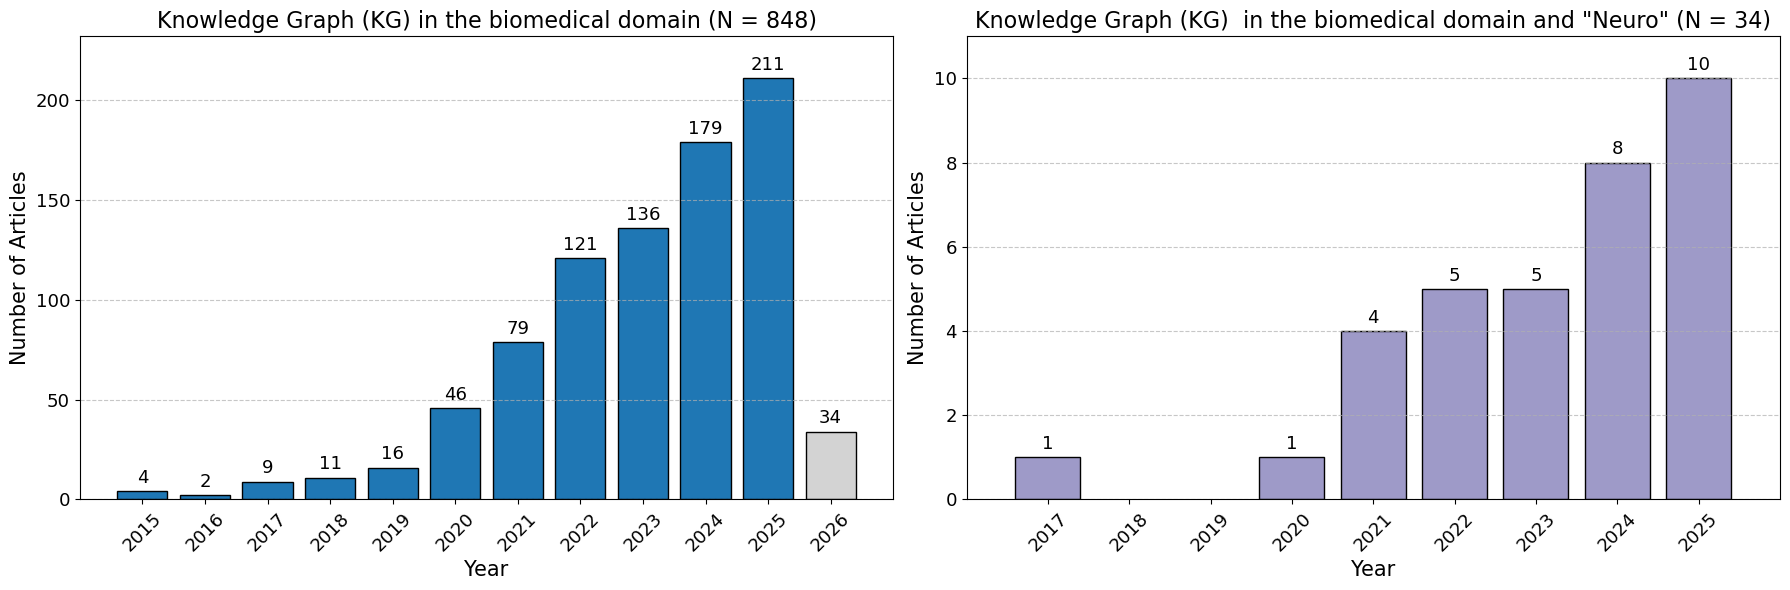

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading and Processing with Pandas
def load_and_count_papers(filepath):
    """
    Reads a tab-separated text file using Pandas, cleans the 'Year' column, 
    and returns a Series with the absolute count of publications per year.
    """
    # Read the file as a pandas DataFrame. 
    # on_bad_lines='skip' ensures that if a line is malformed, the script won't crash.
    df = pd.read_csv(filepath, sep='\t', on_bad_lines='skip')
    
    # Ensure 'Year' is treated as a numeric value and drop any rows with missing/invalid years
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)
    
    # Group by the 'Year' column and count the number of rows (publications) per year
    yearly_counts = df.groupby('Year').size()
    
    return yearly_counts

# Load data for both plots
counts_biomed = load_and_count_papers('KB_biomed_pubmed_all_papers.txt')
counts_neuro = load_and_count_papers('KB_pubmed_NEURO_papers.txt')

# Plotting the Histograms

# Define exact colors
biomed_base_color = '#1f77b4'  
neuro_base_color = '#9E9AC8'    
highlight_2026_color = 'lightgrey' 
edge_color = 'black'


colors_biomed = [highlight_2026_color if year == 2026 else biomed_base_color for year in counts_biomed.index]
colors_neuro = [highlight_2026_color if year == 2026 else neuro_base_color for year in counts_neuro.index]

# Setup the figure and two subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(18, 6)) # Made slightly wider to fit all the labels

# Subplot 1 (Left)
bars_biomed = axs[0].bar(counts_biomed.index, counts_biomed.values, 
                         color=colors_biomed, edgecolor=edge_color, width=0.8, align='center')
axs[0].set_title('Knowledge Graph (KG) in the biomedical domain (N = 848)', fontsize=16)
axs[0].set_xlabel('Year', fontsize=15)
axs[0].set_ylabel('Number of Articles', fontsize=15)

axs[0].bar_label(bars_biomed, padding=3, rotation=0, fontsize=13)

# Subplot 2 (Right)
bars_neuro = axs[1].bar(counts_neuro.index, counts_neuro.values, 
                        color=colors_neuro, edgecolor=edge_color, width=0.8, align='center')
axs[1].set_title('Knowledge Graph (KG)  in the biomedical domain and "Neuro" (N = 34)', fontsize=16)
axs[1].set_xlabel('Year', fontsize=15)
axs[1].set_ylabel('Number of Articles', fontsize=15)

axs[1].bar_label(bars_neuro, padding=3, rotation=0, fontsize=13)


# We apply the same formatting rules to both subplots to ensure they look uniform
for ax, counts in zip(axs, [counts_biomed, counts_neuro]):
    if not counts.empty:
        min_year = int(counts.index.min())
        max_year = int(counts.index.max())
        
        ax.set_xlim(min_year - 1, max_year + 1)
        
        ticks = list(range(min_year, max_year + 1))
        
        ax.set_xticks(ticks)
        
        ax.tick_params(axis='x', rotation=45, labelsize=13) 
        ax.tick_params(axis='y', labelsize=13) 
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        max_val = counts.values.max()
        ax.set_ylim(0, max_val + (max_val * 0.1))

# Final layout adjustment
plt.tight_layout() 

# save the plot
plt.savefig('literatureAnalyses.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()